# House Price Prediction — Data Cleaning, EDA & Model Training

Dataset: [House Price by Juhi Bhojani](https://www.kaggle.com/datasets/juhibhojani/house-price) (Kaggle, ~187,000 Indian property listings).

## 2.1 Load & Inspect

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/house_prices.csv")
df.shape


(187531, 21)

In [ ]:
df.head()


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [ ]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16  Car Parking  

In [ ]:
df.describe()


,Index,Price (in rupees),Dimensions,Plot Area
count,187531.000000,1.698660e+05,0.0,0.0
mean,93765.000000,7.583772e+03,NaN,NaN
std,54135.681003,2.724171e+04,NaN,NaN
min,0.000000,0.000000e+00,NaN,NaN
25%,46882.500000,4.297000e+03,NaN,NaN
50%,93765.000000,6.034000e+03,NaN,NaN
75%,140647.500000,9.450000e+03,NaN,NaN
max,187530.000000,6.700000e+06,NaN,NaN


In [ ]:
df.isna().mean().sort_values(ascending=False)


Plot Area            1.000000
Dimensions           1.000000
Society              0.584853
Super Area           0.574225
Car Parking          0.551146
overlooking          0.434254
Carpet Area          0.430185
facing               0.374514
Ownership            0.349366
Balcony              0.260944
Price (in rupees)    0.094198
Floor                0.037738
Description          0.016120
Furnishing           0.015448
Bathroom             0.004415
Status               0.003279
Transaction          0.000443
Amount(in rupees)    0.000000
Title                0.000000
Index                0.000000
location             0.000000
dtype: float64

**Notes:** fill in row/column counts, numeric vs. text columns, and which columns have the most missing values after running the cells above.

## 2.2 Exploratory Data Analysis (EDA)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


In [ ]:
# We need price_clean first for a meaningful price plot -- see 2.3 below,
# but a quick look at the raw distribution before cleaning is still useful.
df["Amount(in rupees)"].astype(str).str.extract(r"([A-Za-z]+)").value_counts().head(10)


0   
Lac     112568
Cr       65279
Call      9684
Name: count, dtype: int64

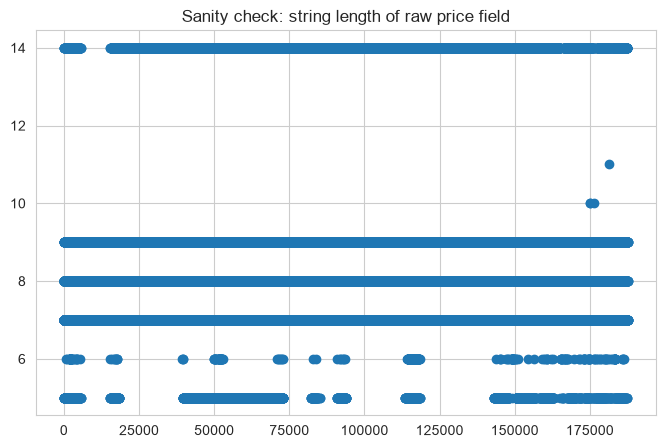

In [ ]:
# Price vs carpet area (raw, before cleaning) -- run again after 2.3 for the clean version
plt.figure(figsize=(8,5))
plt.scatter(range(len(df)), df["Amount(in rupees)"].astype(str).str.len())
plt.title("Sanity check: string length of raw price field")
plt.show()


The four required EDA plots (price distribution, price vs carpet area, average price by top-15 locations, price by furnishing/bathrooms) are built in **section 2.3b**, after cleaning, since they need `price_clean` and `carpet_area_sqft` to be meaningful.

## 2.3 Cleaning & Feature Engineering

### Step 1 — Parse price (`Amount(in rupees)` → `price_clean`)

In [ ]:
def parse_amount(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 1e5
        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 1e7
        return float(x.replace(",", ""))
    except ValueError:
        return None

df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)
df = df.dropna(subset=["price_clean"])
df.shape


(177847, 22)

### Step 2 — Parse area (`Carpet Area` / `Super Area` → `carpet_area_sqft`)

In [ ]:
def parse_area(x):
    """Extract a numeric value in sqft from strings like '1200 sqft' or '140 sqm'."""
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        num = float("".join(ch for ch in x if ch.isdigit() or ch == "."))
        if "sqm" in x or "sq.m" in x:
            return num * 10.764
        return num
    except ValueError:
        return None

df["carpet_area_sqft"] = df["Carpet Area"].apply(parse_area)
# Fall back to Super Area when Carpet Area is missing
if "Super Area" in df.columns:
    super_area_sqft = df["Super Area"].apply(parse_area)
    df["carpet_area_sqft"] = df["carpet_area_sqft"].fillna(super_area_sqft)

df["carpet_area_sqft"].describe()


count    177757.000000
mean       1277.896724
std        2724.499341
min           1.000000
25%         850.000000
50%        1153.000000
75%        1570.000000
max      709222.000000
Name: carpet_area_sqft, dtype: float64

### Step 3 — Parse floor (`Floor` → `floor_num`)

In [ ]:
def parse_floor(x):
    """'3 out of 10' -> 3, 'Ground out of 5' -> 0, 'Basement' -> -1."""
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    first = x.split("out")[0].strip()
    if "ground" in first:
        return 0
    if "basement" in first:
        return -1
    try:
        return int(first)
    except ValueError:
        return None

df["floor_num"] = df["Floor"].apply(parse_floor)
df["floor_num"].describe()


count    170898.000000
mean          4.499029
std           4.701323
min          -1.000000
25%           2.000000
50%           3.000000
75%           6.000000
max         200.000000
Name: floor_num, dtype: float64

### Step 4 — Numeric conversion + imputation for Bathroom / Balcony / Car Parking

In [ ]:
for col in ["Bathroom", "Balcony", "Car Parking"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df["bathroom"] = df["Bathroom"].fillna(df["Bathroom"].median()) if "Bathroom" in df.columns else 0
df["balcony"] = df["Balcony"].fillna(0) if "Balcony" in df.columns else 0


### Step 5 — High-cardinality categoricals: keep top-50 locations, group the rest into 'other'

In [ ]:
TOP_N_LOCATIONS = 50
top_locations = df["location"].value_counts().head(TOP_N_LOCATIONS).index
df["location_grouped"] = df["location"].where(df["location"].isin(top_locations), "other")
df["location_grouped"].value_counts().head(10)


location_grouped
new-delhi        24945
bangalore        23262
kolkata          21605
gurgaon          18846
ahmedabad        12614
hyderabad        11147
chennai          10163
jaipur            7867
greater-noida     4490
faridabad         3733
Name: count, dtype: int64

### Step 6 — Drop useless columns

In [ ]:
cols_to_drop = [c for c in ["Index", "Title", "Description", "Dimensions", "Amount(in rupees)",
                            "Carpet Area", "Super Area", "Floor", "location", "Society",
                            "Bathroom", "Balcony", "Car Parking"] if c in df.columns]
df = df.drop(columns=cols_to_drop)
df.columns.tolist()


['Price (in rupees)',
 'Status',
 'Transaction',
 'Furnishing',
 'facing',
 'overlooking',
 'Ownership',
 'Plot Area',
 'price_clean',
 'carpet_area_sqft',
 'floor_num',
 'bathroom',
 'balcony',
 'location_grouped']

### Step 7 — Remove price-per-sqft outliers (below 1st / above 99th percentile)

In [ ]:
df["price_per_sqft"] = df["price_clean"] / df["carpet_area_sqft"].replace(0, np.nan)
low, high = df["price_per_sqft"].quantile([0.01, 0.99])
before = len(df)
df = df[(df["price_per_sqft"] >= low) & (df["price_per_sqft"] <= high)]
df = df.drop(columns=["price_per_sqft"])
print(f"Dropped {before - len(df)} outlier rows, {len(df)} remain")


Dropped 3376 outlier rows, 174471 remain


## 2.3b EDA on the cleaned data (the 4 required plots)

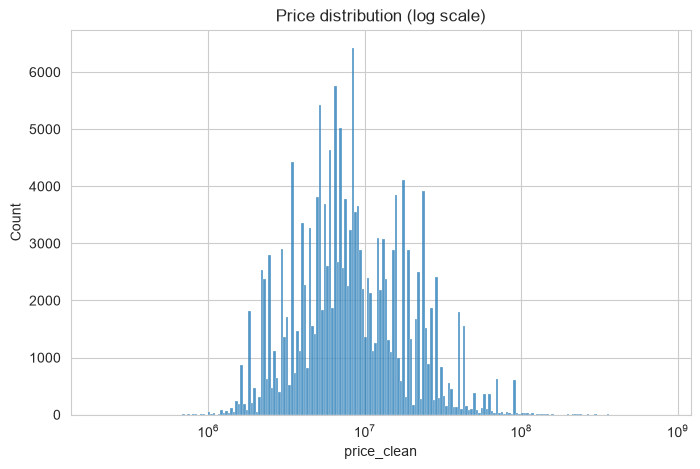

In [ ]:
# 1) Distribution of price (log scale)
plt.figure(figsize=(8,5))
sns.histplot(df["price_clean"], log_scale=True)
plt.title("Price distribution (log scale)")
plt.show()


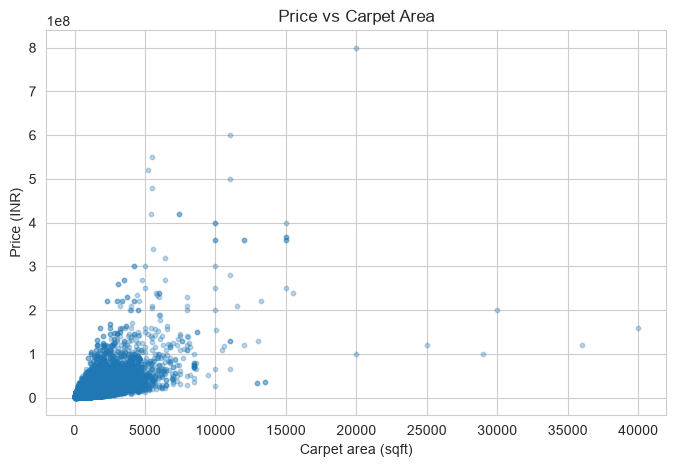

In [ ]:
# 2) Price vs carpet area
plt.figure(figsize=(8,5))
plt.scatter(df["carpet_area_sqft"], df["price_clean"], alpha=0.3, s=10)
plt.xlabel("Carpet area (sqft)")
plt.ylabel("Price (INR)")
plt.title("Price vs Carpet Area")
plt.show()


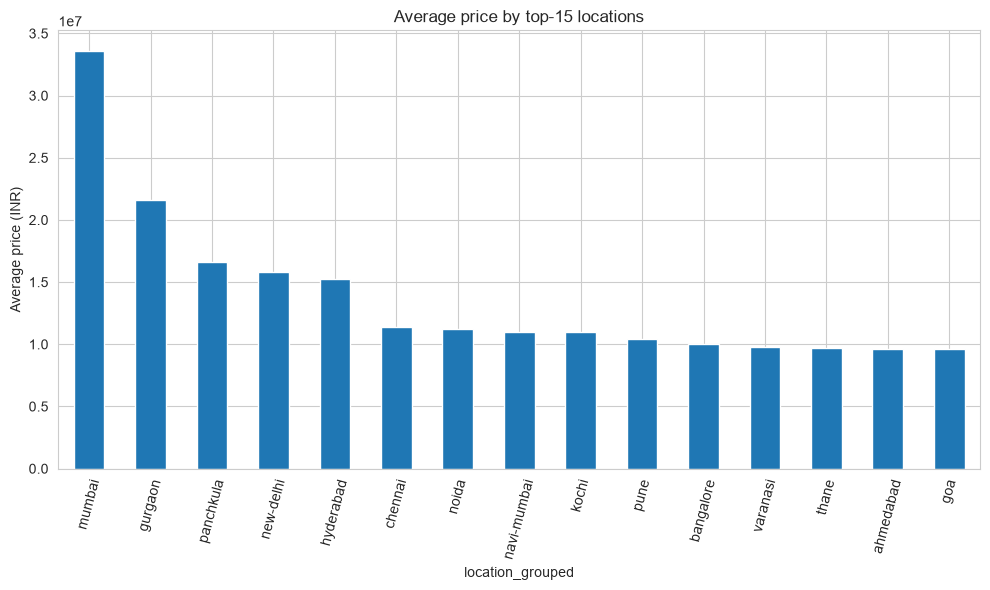

In [ ]:
# 3) Average price by top-15 locations
top15 = df.groupby("location_grouped")["price_clean"].mean().sort_values(ascending=False).head(15)
plt.figure(figsize=(10,6))
top15.plot(kind="bar")
plt.ylabel("Average price (INR)")
plt.title("Average price by top-15 locations")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()


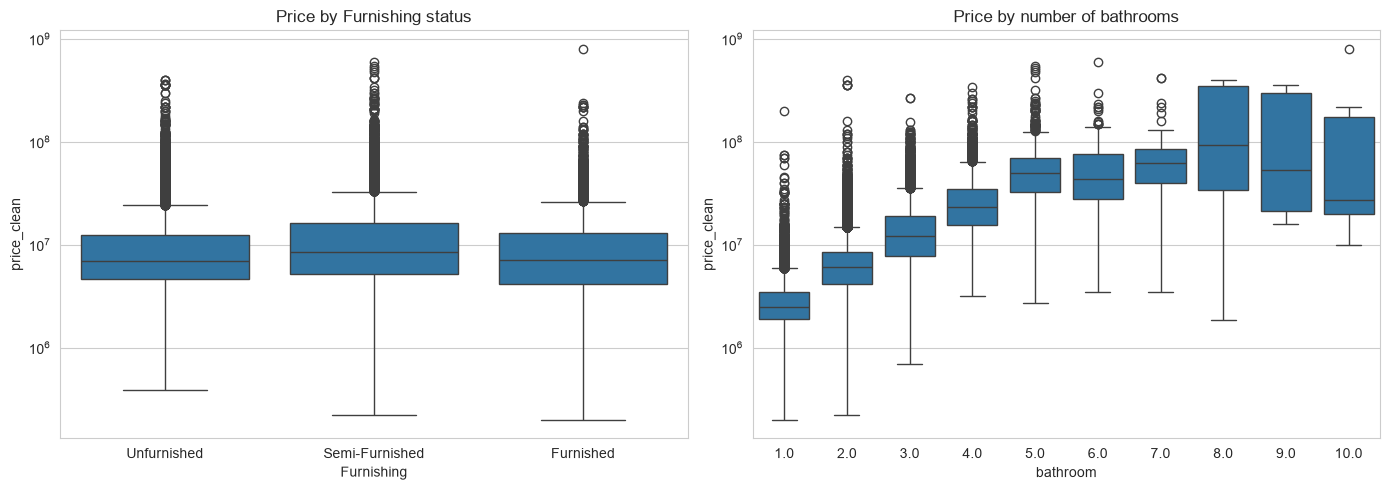

In [ ]:
# 4) Price by furnishing status / number of bathrooms (box plots)
fig, axes = plt.subplots(1, 2, figsize=(14,5))
if "Furnishing" in df.columns:
    sns.boxplot(data=df, x="Furnishing", y="price_clean", ax=axes[0])
    axes[0].set_yscale("log")
    axes[0].set_title("Price by Furnishing status")
sns.boxplot(data=df, x="bathroom", y="price_clean", ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Price by number of bathrooms")
plt.tight_layout()
plt.show()


**Comment on the plots above:** add a short written interpretation for each of the four plots here.

## 2.4 Build a Pipeline & Train

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

numeric_features = ["carpet_area_sqft", "floor_num", "bathroom", "balcony"]
categorical_features = [c for c in ["location_grouped", "Furnishing", "Transaction", "Ownership", "facing"] if c in df.columns]

preprocessor = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                       ("scale", StandardScaler())]), numeric_features),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                       ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_features),
])

X = df[numeric_features + categorical_features]
y = df["price_clean"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# Baseline model: Linear Regression
linreg_model = Pipeline([("prep", preprocessor),
                          ("reg", LinearRegression())])
linreg_model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['carpet_area_sqft','floor_num','bathroom',...,'Transaction','Ownership', 'facing']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columns

In [24]:
# Main model: Random Forest
rf_model = Pipeline([("prep", preprocessor),
                      ("reg", RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1))])
rf_model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['carpet_area_sqft','floor_num','bathroom',...,'Transaction','Ownership', 'facing']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columns

**Tip:** since price is skewed, training on `np.log1p(y)` and inverting with `np.expm1` at prediction time often improves results. Try it below and compare.

In [26]:
# Random Forest trained on log-transformed target
rf_log_model = Pipeline([("prep", preprocessor),
                          ("reg", RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1))])
rf_log_model.fit(X_train, np.log1p(y_train))


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['carpet_area_sqft','floor_num','bathroom',...,'Transaction','Ownership', 'facing']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columns

## 2.5 Evaluate

In [27]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

def evaluate(name, model, log_target=False):
    pred = model.predict(X_test)
    if log_target:
        pred = np.expm1(pred)
    mae = mean_absolute_error(y_test, pred)
    rmse = root_mean_squared_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    print(f"{name:25s} MAE: {mae:,.0f}   RMSE: {rmse:,.0f}   R2: {r2:.3f}")
    return {"name": name, "mae": mae, "rmse": rmse, "r2": r2, "pred": pred}

results = []
results.append(evaluate("Linear Regression", linreg_model))
results.append(evaluate("Random Forest", rf_model))
results.append(evaluate("Random Forest (log target)", rf_log_model, log_target=True))


Linear Regression         MAE: 4,521,805   RMSE: 8,407,485   R2: 0.621
Random Forest             MAE: 1,022,647   RMSE: 5,255,358   R2: 0.852
Random Forest (log target) MAE: 983,779   RMSE: 5,450,022   R2: 0.841


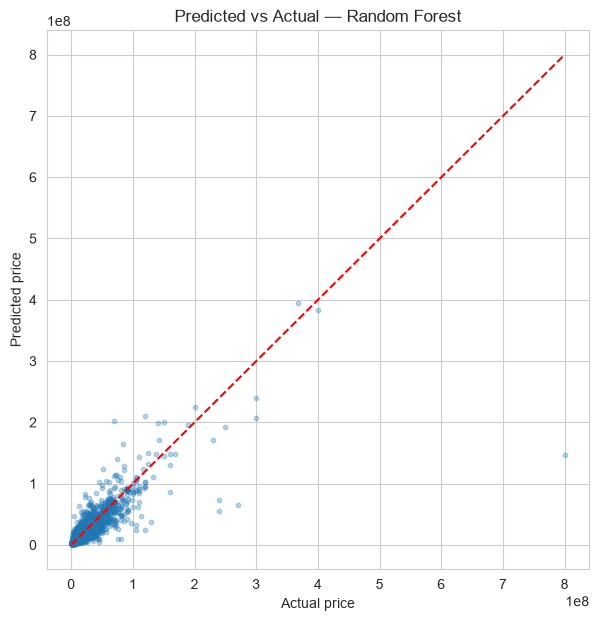

In [28]:
# Predicted vs actual scatter for the best-looking model so far
best = max(results, key=lambda r: r["r2"])
plt.figure(figsize=(7,7))
plt.scatter(y_test, best["pred"], alpha=0.3, s=10)
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, "r--")
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title(f"Predicted vs Actual — {best['name']}")
plt.show()


In [29]:
import pandas as pd
comparison = pd.DataFrame(results)[["name", "mae", "rmse", "r2"]]
comparison


,name,mae,rmse,r2
0,Linear Regression,4.521805e+06,8.407485e+06,0.621448
1,Random Forest,1.022647e+06,5.255358e+06,0.852090
2,Random Forest (log target),9.837794e+05,5.450022e+06,0.840930


**Conclusion:** state which model wins and why, based on the comparison table above (usually the Random Forest, log target or not, depending on your results).

In [30]:
# Bonus: 5-fold cross-validation on the winning pipeline
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring="r2")
print("CV R2 scores:", cv_scores)
print("Mean CV R2:", cv_scores.mean())


CV R2 scores: [0.83250759 0.25532736 0.93160507 0.38053879 0.06588815]
Mean CV R2: 0.49317339043474623


## 2.6 Export the Model

In [31]:
import joblib

# Pick whichever pipeline performed best above -- rf_model is used here as the default
FINAL_MODEL = rf_model

joblib.dump(FINAL_MODEL, "house_price.pkl")

# Sanity check: reload and predict one sample
loaded = joblib.load("house_price.pkl")
sample = X_test.iloc[[0]]
print("Reloaded prediction:", loaded.predict(sample))


Reloaded prediction: [7000000.]


In [32]:
import json

json.dump(sorted(df["location_grouped"].unique().tolist()), open("locations.json", "w"))


In [33]:
import sklearn
print("scikit-learn version:", sklearn.__version__)
# Pin this exact version in backend/requirements.txt


scikit-learn version: 1.9.0
